In [1]:
 import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = {
    'Hours_Studied': [2, 3, 4, 5, 6, 7, 8, 9, 1, 3, 6, 8],
    'Attendance': [60, 65, 70, 75, 80, 85, 90, 95, 50, 68, 82, 92],
    'Previous_Score': [45, 50, 55, 60, 65, 70, 75, 85, 40, 52, 68, 78],
    'Pass': [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)


X = df[['Hours_Studied', 'Attendance', 'Previous_Score']]
y = df['Pass']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Bagging - Random Forest")
print("Predictions:", rf_pred)
print("Accuracy:", accuracy_score(y_test, rf_pred))


dt = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=dt,
    n_estimators=10,
    random_state=42
)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

print("\nBoosting - AdaBoost")
print("Predictions:", ada_pred)
print("Accuracy:", accuracy_score(y_test, ada_pred))


Bagging - Random Forest
Predictions: [1 0 0]
Accuracy: 1.0

Boosting - AdaBoost
Predictions: [1 0 0]
Accuracy: 1.0


Dataset:
    StudyHours  Attendance  Assignments  Pass
0            2          60            3     0
1            5          85            8     1
2            1          55            2     0
3            6          90            9     1
4            3          70            5     0
5            8          95           10     1
6            2          65            4     0
7            7          88            9     1
8            4          75            6     1
9            9          98           10     1
10           1          50            1     0
11           5          82            7     1
12           6          91            9     1
13           3          68            4     0
14           8          94           10     1
15           2          58            3     0
16           7          89            8     1
17           4          72            5     0
18           9          97           10     1
19           3          65            4     0

Bagging Performance
Accu

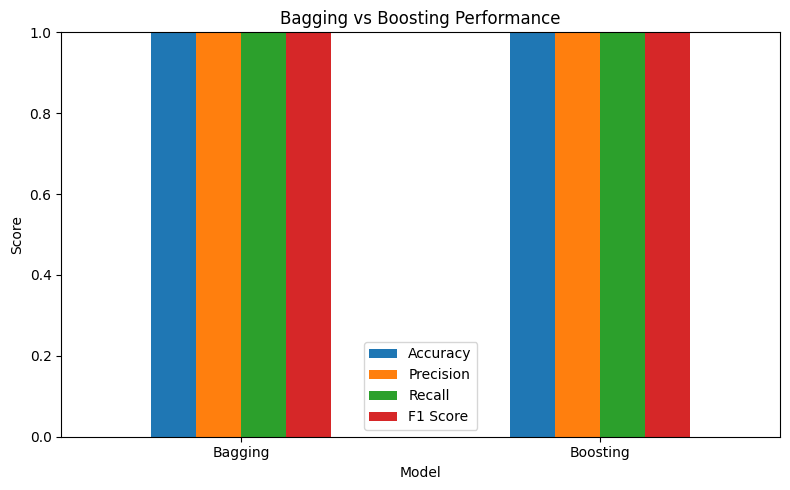

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = {
    "StudyHours": [2, 5, 1, 6, 3, 8, 2, 7, 4, 9, 1, 5, 6, 3, 8, 2, 7, 4, 9, 3],
    "Attendance": [60, 85, 55, 90, 70, 95, 65, 88, 75, 98, 50, 82, 91, 68, 94, 58, 89, 72, 97, 65],
    "Assignments": [3, 8, 2, 9, 5, 10, 4, 9, 6, 10, 1, 7, 9, 4, 10, 3, 8, 5, 10, 4],
    "Pass": [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

X = df[["StudyHours", "Attendance", "Assignments"]]
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)

boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=10,
    random_state=42
)

bagging.fit(X_train, y_train)
boosting.fit(X_train, y_train)

bagging_pred = bagging.predict(X_test)
boosting_pred = boosting.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_precision = precision_score(y_test, bagging_pred)
bagging_recall = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

boosting_accuracy = accuracy_score(y_test, boosting_pred)
boosting_precision = precision_score(y_test, boosting_pred)
boosting_recall = recall_score(y_test, boosting_pred)
boosting_f1 = f1_score(y_test, boosting_pred)

results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy],
    "Precision": [bagging_precision, boosting_precision],
    "Recall": [bagging_recall, boosting_recall],
    "F1 Score": [bagging_f1, boosting_f1]
})

print("\nBagging Performance")
print("Accuracy:", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall:", bagging_recall)
print("F1 Score:", bagging_f1)

print("\nBoosting Performance")
print("Accuracy:", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall:", boosting_recall)
print("F1 Score:", boosting_f1)

print("\nPerformance Comparison")
print(results)

results.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

